# Aerial Images Classification using Convolutional Autoencoder

<u>Considered Classes</u>

- Agriculture 
- Airport
- Beach
- City

[Dataset](https://www.kaggle.com/datasets/ankit1743/skyview-an-aerial-landscape-dataset)

Each class consists of 800 images.

### 1. Reading Data

In [39]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc, recall_score, precision_score, roc_auc_score

In [40]:
dataset_dir_train = "./Aerial_Landscapes/"

# Initialize lists to store images and labels
images = []
labels = []

# Counter to keep track of the number of classes processed
class_count = 0

# Loop through each class label in the dataset directory
for class_label in os.listdir(dataset_dir_train):
    if class_count >= 4:
        break

    class_dir = os.path.join(dataset_dir_train, class_label)

    # Check if it's a directory
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            image_path = os.path.join(class_dir, filename)
            image = cv2.imread(image_path)

            # Resize and preprocess the image as needed
            image = cv2.resize(image, (224, 224))
            image = image / 255.0  # Normalize pixel values

            images.append(image)
            labels.append(class_label)

        class_count += 1

# Convert lists to NumPy arrays
images = np.array(images)
labels = np.array(labels)

# Give the shape
print(images.shape)
print(labels.shape)

(3200, 224, 224, 3)
(3200,)


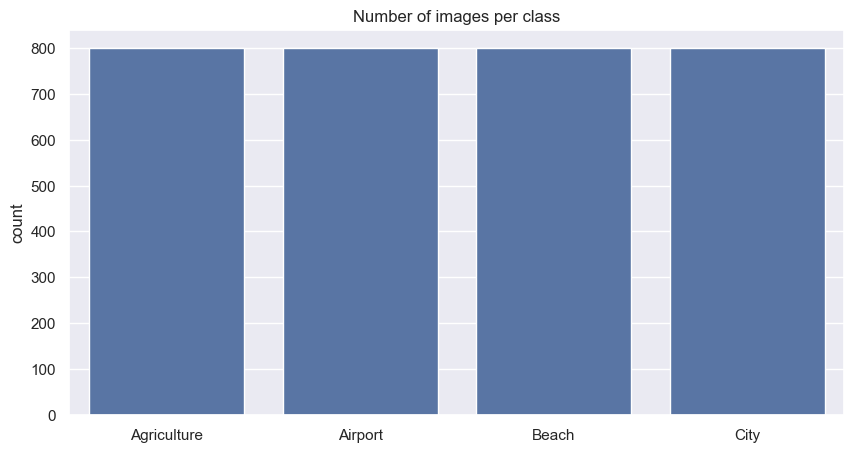

In [41]:
# PLOT the Class Distribution
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

# Plot the number of images per class
plt.figure(figsize=(10, 5))
sns.countplot(x=labels)
plt.title('Number of images per class')
plt.show()


### 2. Build an Autoencoder

In [3]:
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from keras.models import Model
from keras.losses import MeanAbsoluteError, BinaryCrossentropy
from keras.optimizers import Adam

def cae(shape):
    input_img = Input(shape=shape)

    # Encoder
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)
    x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Conv2DTranspose(16, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2DTranspose(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(), loss='mse', metrics=[MeanAbsoluteError(), BinaryCrossentropy()])

    return autoencoder

# Build the model
autoencoder = cae((224, 224, 3))
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 16)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 64)        18496 

### 3. Train Autoencoder

In [4]:
#train the model with GPU
import tensorflow as tf
with tf.device('/device:GPU:0'):
    autoencoder.fit(
        images, 
        images, 
        epochs=50, 
        batch_size=64, 
        shuffle=True,
        validation_split=0.2,
        verbose=1  
    )

Epoch 1/50
40/40 [==============================] - 14s 146ms/step - loss: 0.0212 - mean_absolute_error: 0.1116 - binary_crossentropy: 0.6541 - val_loss: 0.0150 - val_mean_absolute_error: 0.0950 - val_binary_crossentropy: 0.5956
Epoch 2/50
40/40 [==============================] - 5s 126ms/step - loss: 0.0069 - mean_absolute_error: 0.0609 - binary_crossentropy: 0.6229 - val_loss: 0.0117 - val_mean_absolute_error: 0.0804 - val_binary_crossentropy: 0.5878
Epoch 3/50
40/40 [==============================] - 5s 126ms/step - loss: 0.0055 - mean_absolute_error: 0.0523 - binary_crossentropy: 0.6194 - val_loss: 0.0105 - val_mean_absolute_error: 0.0755 - val_binary_crossentropy: 0.5847
Epoch 4/50
40/40 [==============================] - 5s 127ms/step - loss: 0.0047 - mean_absolute_error: 0.0478 - binary_crossentropy: 0.6176 - val_loss: 0.0100 - val_mean_absolute_error: 0.0740 - val_binary_crossentropy: 0.5834
Epoch 5/50
40/40 [==============================] - 5s 127ms/step - loss: 0.0044 - mean

### 4. Plot Reconstruction Errors

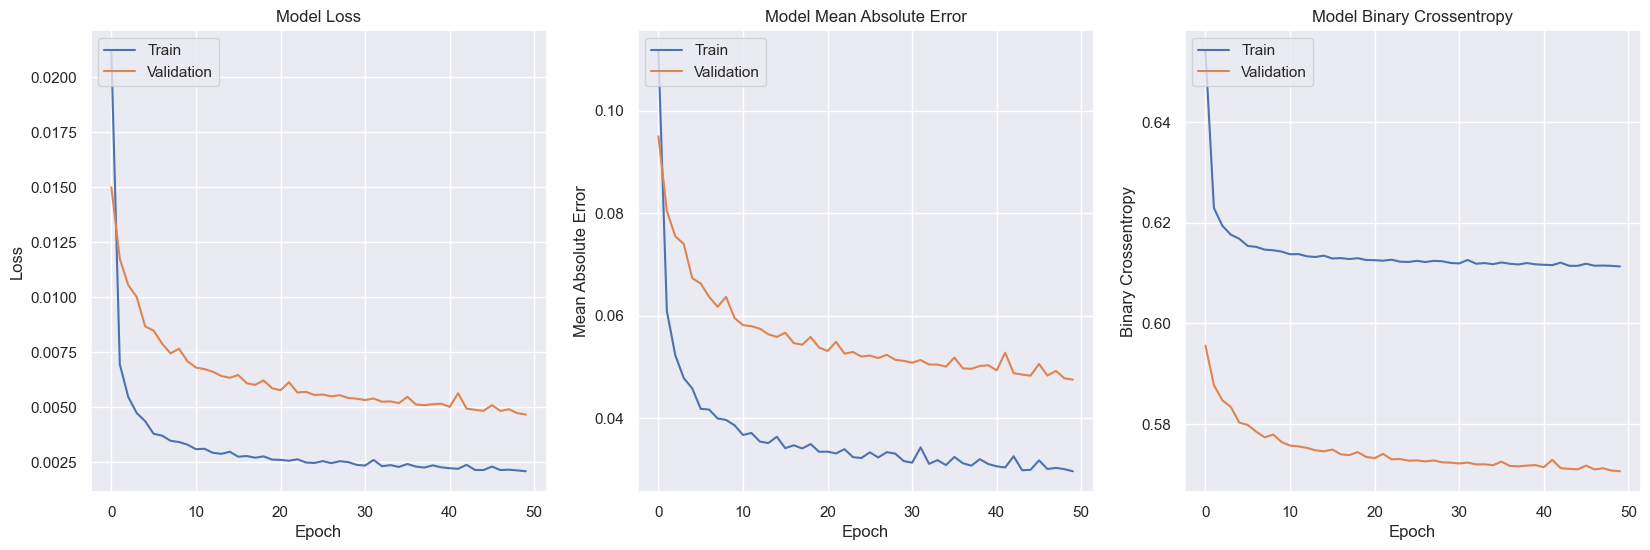

In [7]:
#plot the loss
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.plot(autoencoder.history.history['loss'])
plt.plot(autoencoder.history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

#plot MEAN ABSOLUTE ERROR
plt.subplot(1, 3, 2)
plt.plot(autoencoder.history.history['mean_absolute_error'])
plt.plot(autoencoder.history.history['val_mean_absolute_error'])
plt.title('Model Mean Absolute Error')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

#plot BINARY CROSS ENTROPY
plt.subplot(1, 3, 3)
plt.plot(autoencoder.history.history['binary_crossentropy'])
plt.plot(autoencoder.history.history['val_binary_crossentropy'])
plt.title('Model Binary Crossentropy')
plt.ylabel('Binary Crossentropy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [8]:
#Save the model
autoencoder.save("autoencoder.h5")



In [9]:
#Extract The encoder part of the model
encoder = Model(
    inputs=autoencoder.input, 
    outputs=autoencoder.get_layer('max_pooling2d_2').output
)

#Save the encoder model
encoder.save("encoder.h5")

### 5. Extract Features

In [10]:
#extract features
features = encoder.predict(images)

#print the shape of the features
print(features.shape)

100/100 [==============================] - 1s 7ms/step
(3200, 28, 28, 64)


In [11]:
# save the features
np.save("features.npy", features)

### 6. Split into Train and Test

In [12]:
# split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

#print shape
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2560, 28, 28, 64)
(2560,)
(640, 28, 28, 64)
(640,)


In [13]:
y_train = LabelEncoder().fit_transform(y_train)
y_test = LabelEncoder().fit_transform(y_test)

#one hot encoding 
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)



### 7. Build an Dense Network

Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 28, 28, 64)]      0         
                                                                 
 flatten_5 (Flatten)         (None, 50176)             0         
                                                                 
 dense_20 (Dense)            (None, 64)                3211328   
                                                                 
 dense_21 (Dense)            (None, 32)                2080      
                                                                 
 dense_22 (Dense)            (None, 16)                528       
                                                                 
 dense_23 (Dense)            (None, 4)                 68        
                                                                 
Total params: 3,214,004
Trainable params: 3,214,004
Non-tra

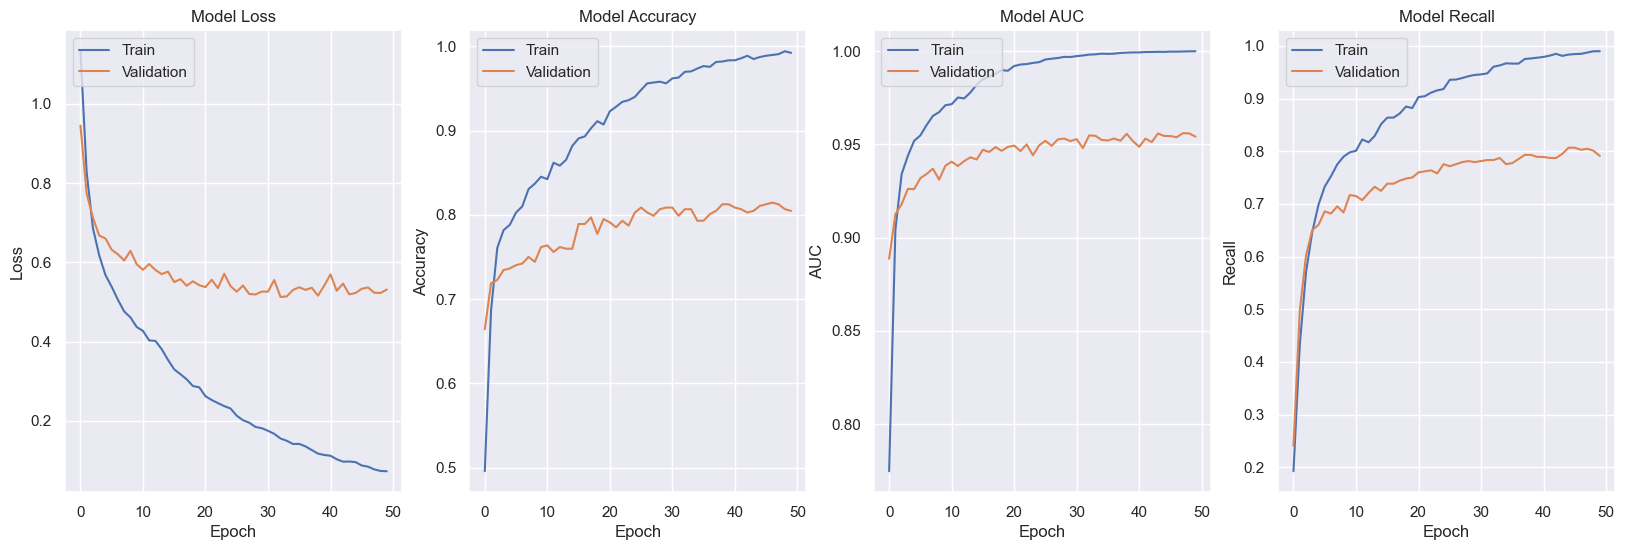

In [23]:
from keras.layers import Dense, Dropout, Input, Flatten
from keras.models import Model
from keras.optimizers import Adam

def ann(input_shape, num_classes):
    inps = Input(shape=input_shape)  

    f = Flatten()(inps)

    x = Dense(64, activation='relu')(f)
    x = Dense(32, activation='relu')(x)
    x = Dense(16, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inps, outputs=out)

    model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=[
        'accuracy', 
        'AUC', 
        'Recall', 
        'Precision'
    ])

    return model

# Assuming X_train has shape (2560, 28, 28, 64)
input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3])
num_classes = 4

# Build the model
model = ann(input_shape, num_classes)
model.summary()

#train the model with GPU
import tensorflow as tf
with tf.device('/device:GPU:0'):
    model.fit(
        X_train, 
        y_train, 
        epochs=50, 
        batch_size=64, 
        shuffle=True,
        validation_split=0.2,
        verbose=1  
    )

#plot the loss
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

plt.figure(figsize=(20, 6))

plt.subplot(1, 4, 1)
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

#plot accuracy
plt.subplot(1, 4, 2)
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

#plot AUC
plt.subplot(1, 4, 3)
plt.plot(model.history.history['auc'])
plt.plot(model.history.history['val_auc'])
plt.title('Model AUC')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

#plot Recall
plt.subplot(1, 4, 4)
plt.plot(model.history.history['recall'])
plt.plot(model.history.history['val_recall'])
plt.title('Model Recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [29]:
#predict the model on the test data and print the classification report

y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

print(y_pred_labels.shape)

20/20 [==============================] - 0s 4ms/step
(640,)


### 8. Evaluate the Classifier

In [33]:
# Print the classification report
print(classification_report(y_test, y_pred_labels))

# Print the confusion matrix
print(confusion_matrix(y_test, y_pred_labels))

# Print the accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_labels))

# Print the F1 score
print("F1 Score:", f1_score(y_test, y_pred_labels, average='weighted'))

# Print the Recall score
print("Recall Score:", recall_score(y_test, y_pred_labels, average='weighted'))

# Print the Precision score
print("Precision Score:", precision_score(y_test, y_pred_labels, average='weighted'))





              precision    recall  f1-score   support

           0       0.80      0.89      0.84       188
           1       0.79      0.72      0.75       155
           2       0.87      0.88      0.88       164
           3       0.93      0.86      0.89       133

    accuracy                           0.84       640
   macro avg       0.85      0.84      0.84       640
weighted avg       0.84      0.84      0.84       640

[[167   8  11   2]
 [ 30 112   8   5]
 [  9   9 145   1]
 [  4  13   2 114]]
Accuracy: 0.840625
F1 Score: 0.8401719692242157
Recall Score: 0.840625
Precision Score: 0.8426405993817273


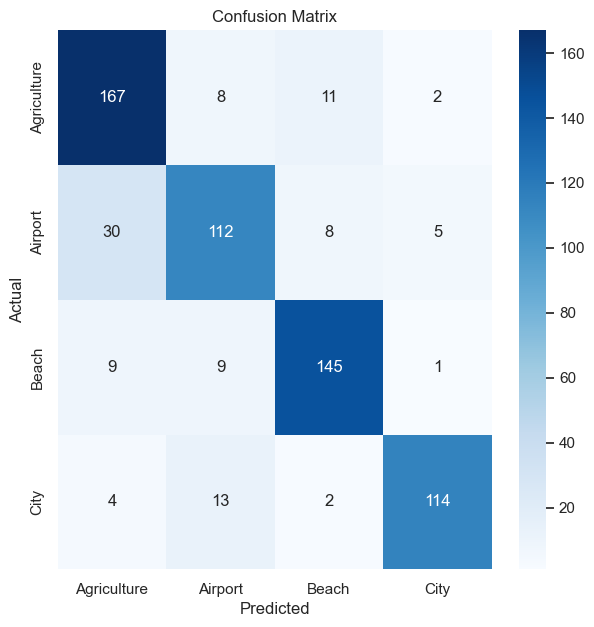

In [35]:
#plot the confusion matrix

# 0 - Agriculture, 1 - Airport, 2 - Beach, 3 - City
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(7,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Agriculture', 'Airport', 'Beach', 'City'], yticklabels=['Agriculture', 'Airport', 'Beach', 'City'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


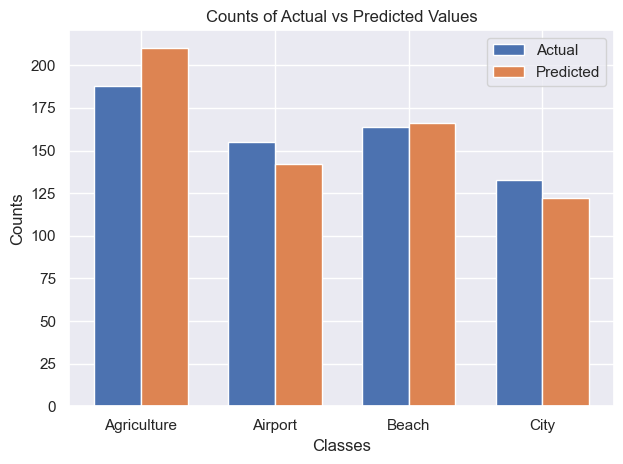

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_test is in label encoded format and y_pred is the predicted probabilities
y_pred_labels = np.argmax(y_pred, axis=1)

# Count the occurrences of each class in y_test and y_pred_labels
actual_counts = np.bincount(y_test, minlength=4)
predicted_counts = np.bincount(y_pred_labels, minlength=4)

# Plot the counts
labels = ['Agriculture', 'Airport', 'Beach', 'City']
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, actual_counts, width, label='Actual')
rects2 = ax.bar(x + width/2, predicted_counts, width, label='Predicted')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Classes')
ax.set_ylabel('Counts')
ax.set_title('Counts of Actual vs Predicted Values')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()

plt.show()

In [37]:
# Save the model
model.save("model.h5")